Supervised Machine Learning Project
Customer Churn Prediction for a Telecom Company
Business Problem:
<br>
Telecom companies lose millions because customers cancel their subscription.

Your job is to predict which customer will leave so the company can take action.
<br>

Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

ML Problem Type

This is a Supervised Classification Problem

Input → Customer details
Output → Will the customer leave? (Yes / No)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### Data Cleaning

In [3]:
df.drop("customerID", axis=1,inplace=True)

df["TotalCharges"] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].fillna(df["TotalCharges"].mean(),inplace=True)

/tmp/ipython-input-3563953770.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df["TotalCharges"].mean(),inplace=True)


#### Exploratory Data Analysis

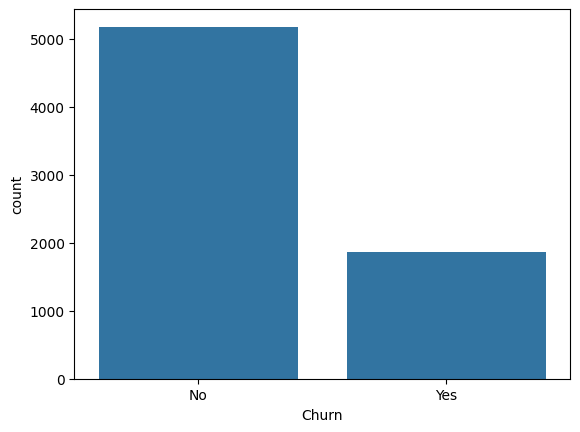

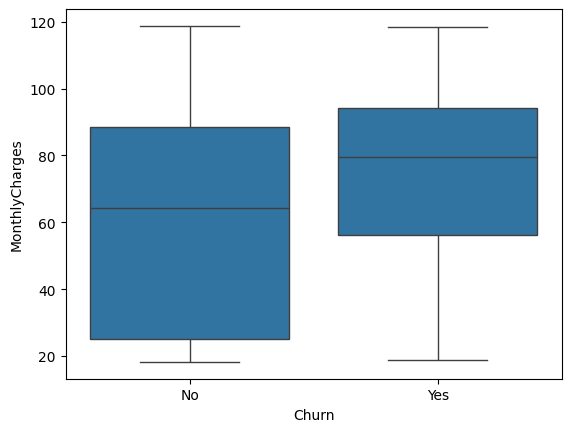

In [4]:
sns.countplot(x="Churn",data=df)
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges",data=df)
plt.show()

#### Target Column

In [5]:
df['Churn'] = df['Churn'].map({"Yes":1,"No":0})

df['Churn'].head()

,Churn
0,0
1,0
2,1
3,0
4,1


In [7]:
cat_cols = df.select_dtypes('object').columns

encoder = LabelEncoder()

for col in cat_cols:
  df[col] = encoder.fit_transform(df[col])

In [8]:
# Split X and Y

X = df.drop("Churn",axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#### Train Models

In [10]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [11]:
# Random Forest

rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [12]:
# Model Evaluation

y_pred = rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.7977288857345636
[[950  86]
 [199 174]]
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.78      1409



#### Feature Importance

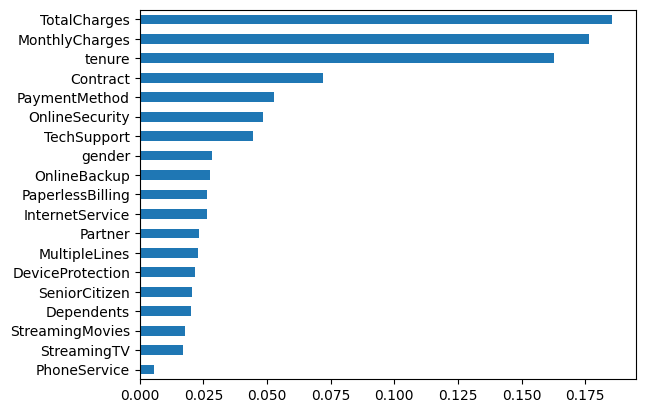

In [13]:
imp = pd.Series(rf.feature_importances_,index=X.columns)
imp.sort_values().plot(kind='barh')
plt.show()

#### Prediction on New Customer

In [22]:
X.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [20]:
new_customer = pd.DataFrame([{
    'gender': 1,
    'SeniorCitizen': 0,
    'Partner': 1,
    'Dependents': 0,
    'tenure': 45,
    'PhoneService': 1,
    'MultipleLines': 1,
    'InternetService': 0,
    'OnlineSecurity': 0,
    'OnlineBackup': 1,
    'DeviceProtection': 1,
    'TechSupport': 1,
    'StreamingTV': 0,
    'StreamingMovies': 1,
    'Contract': 1,
    'PaperlessBilling': 1,
    'PaymentMethod': 2,
    'MonthlyCharges': 75,
    'TotalCharges': 3500
}])


In [21]:
prediction = rf.predict(new_customer)

if prediction[0] == 1:
    print("Customer Will Leave (Churn)")
else:
    print("Customer Will Stay")

Customer Will Stay
